# Predicting Credit Card Customer Default Risk Using Machine Learning

## Project Overview

The purpose of this project is to analyze credit card customer data and develop machine learning models capable of predicting whether a customer is likely to default on their credit card payment in the following month. Credit card default prediction is an important problem for financial institutions because it helps reduce financial losses and improve lending decisions.

This project will use the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. The analysis will include exploratory data analysis, data preprocessing, visualization, and machine learning classification models to identify the most important factors associated with default risk.

## 1. Import Libraries

In [36]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

The dataset is loaded into a Pandas DataFrame for analysis. This dataset contains demographic and financial information about credit card clients in Taiwan, including payment history and default status.

In [37]:
# Load dataset
df = pd.read_csv('UCI_Credit_Card.csv')

# Display first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3. Check Dataset Structure

## Initial Data Exploration

Before building machine learning models, it is important to understand the structure of the dataset, including the number of rows, columns, data types, and potential missing values.

In [38]:
# Shape of dataset
print("Dataset Shape:")
print(df.shape)

print("\n")

# Column names
print("Column Names:")
print(df.columns)

print("\n")

# Dataset information
df.info()

Dataset Shape:
(30000, 25)


Column Names:
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 n

## 4. Check Missing Values

In [39]:
# Check missing values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

## 5. Describe Numerical Variables
## Summary Statistics

The following table provides descriptive statistics for the numerical variables in the dataset, including mean, standard deviation, minimum, and maximum values.

In [40]:
# Summary statistics
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 6. Rename Columns

Some column names in the original dataset are difficult to interpret. Renaming selected variables improves readability and makes the analysis easier to understand.

In [41]:
# Rename columns
df.rename(columns={
    'default.payment.next.month': 'Default_Next_Month',
    'LIMIT_BAL': 'Credit_Limit',
    'SEX': 'Gender',
    'EDUCATION': 'Education',
    'MARRIAGE': 'Marriage',
    'AGE': 'Age'
}, inplace=True)

# Display updated columns
df.columns

Index(['ID', 'Credit_Limit', 'Gender', 'Education', 'Marriage', 'Age', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'Default_Next_Month'],
      dtype='object')

## 7. Remove ID Column

The ID column is removed because it is only a customer identifier and does not contribute to predicting default risk.

In [42]:
# Remove ID column
df.drop('ID', axis=1, inplace=True)

# Verify removal
df.head()

,Credit_Limit,Gender,Education,Marriage,Age,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_Next_Month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 8. Distribution of Default and Non-Default Customers

Understanding the distribution of the target variable is important before building machine learning models. This visualization shows the number of customers who defaulted on their credit card payment compared to those who did not default.

In [43]:
# Count default vs non-default customers
df['Default_Next_Month'].value_counts()

Default_Next_Month
0    23364
1     6636
Name: count, dtype: int64

## 9. Visualization of Default Distribution

The following chart visualizes the number of customers who defaulted versus customers who did not default on their credit card payment the following month.

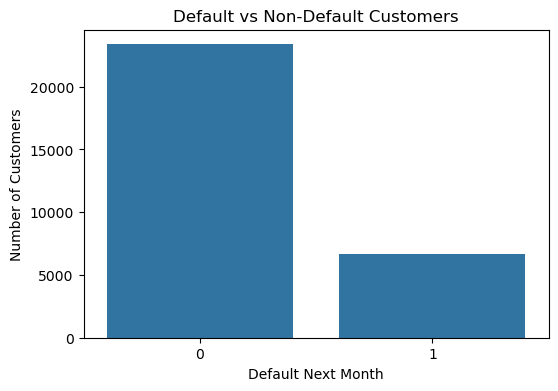

In [44]:
# Plot default distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Default_Next_Month', data=df)

plt.title('Default vs Non-Default Customers')
plt.xlabel('Default Next Month')
plt.ylabel('Number of Customers')

plt.show()

### Interpretation

The dataset contains a larger number of non-default customers compared to default customers. This indicates that the dataset is somewhat imbalanced, which is common in financial datasets involving fraud or default prediction. Class imbalance may affect model performance and will need to be considered during model evaluation.

## 10. Default Rates by Gender

This analysis examines whether default rates differ between male and female credit card customers.

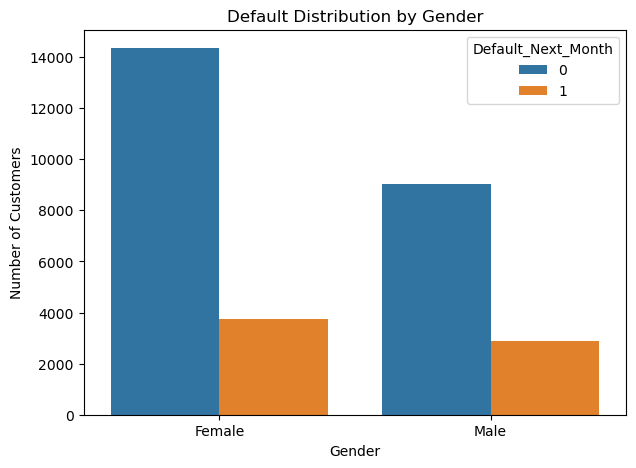


Gender Default Summary Table:

Default_Next_Month      0     1    All
Gender                                
Female              14349  3763  18112
Male                 9015  2873  11888
All                 23364  6636  30000

Default Rate by Gender (%):

Gender
Female    20.776281
Male      24.167227
Name: Default_Next_Month, dtype: float64


In [45]:
# Create temporary dataframe for plotting
gender_plot_df = df.copy()

# Replace gender codes ONLY in temporary dataframe
gender_plot_df['Gender'] = gender_plot_df['Gender'].replace({
    1: 'Male',
    2: 'Female'
})

# Plot gender distribution by default
plt.figure(figsize=(7,5))

sns.countplot(
    x='Gender',
    hue='Default_Next_Month',
    data=gender_plot_df
)

plt.title('Default Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

# Create summary table
gender_summary = pd.crosstab(
    gender_plot_df['Gender'],
    gender_plot_df['Default_Next_Month'],
    margins=True
)

print("\nGender Default Summary Table:\n")
print(gender_summary)

# Calculate default percentage by gender
gender_default_rate = (
    gender_plot_df.groupby('Gender')['Default_Next_Month']
    .mean() * 100
)

print("\nDefault Rate by Gender (%):\n")
print(gender_default_rate)

### Interpretation

The visualization compares default behavior between male and female customers. Observing differences in default rates between demographic groups may help identify patterns associated with credit risk. However, demographic variables should be interpreted carefully to avoid biased conclusions or unfair lending practices.

## 11. Age Distribution of Customers

The following visualization examines the age distribution of customers in the dataset and explores whether age appears related to default behavior.

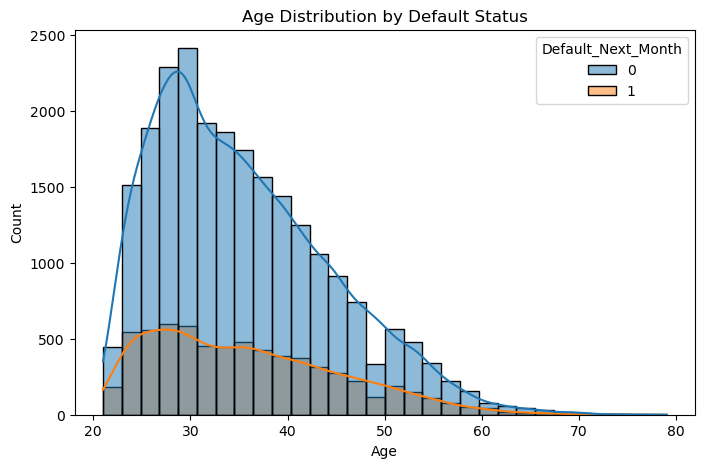

In [46]:
# Plot age distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Default_Next_Month',
    bins=30,
    kde=True
)

plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

### Interpretation

The age distribution visualization helps identify whether certain age groups appear more likely to default on credit card payments. Patterns observed in the distribution may indicate differences in financial behavior or borrowing habits across age categories.

## 12. Credit Limit Analysis

Credit limits may influence customer borrowing behavior and default risk. The following visualization explores the relationship between credit card limits and default status.

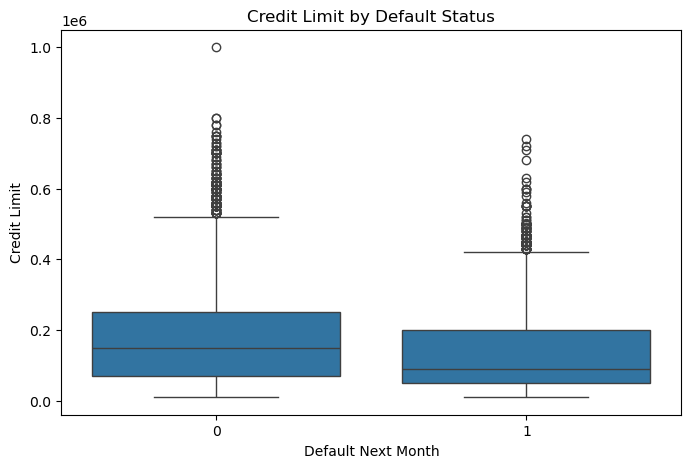

In [47]:
# Plot credit limit distribution
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Default_Next_Month',
    y='Credit_Limit',
    data=df
)

plt.title('Credit Limit by Default Status')
plt.xlabel('Default Next Month')
plt.ylabel('Credit Limit')

plt.show()

### Interpretation

The boxplot illustrates differences in credit limits between customers who defaulted and those who did not. Visual differences in the distribution may suggest that credit limit size has some relationship with default risk, although additional analysis is required to confirm the strength of this relationship.

## 13. Correlation Analysis

Correlation analysis helps identify relationships between variables in the dataset. The heatmap below visualizes the strength of correlations between numerical features and may help identify variables strongly associated with default risk.

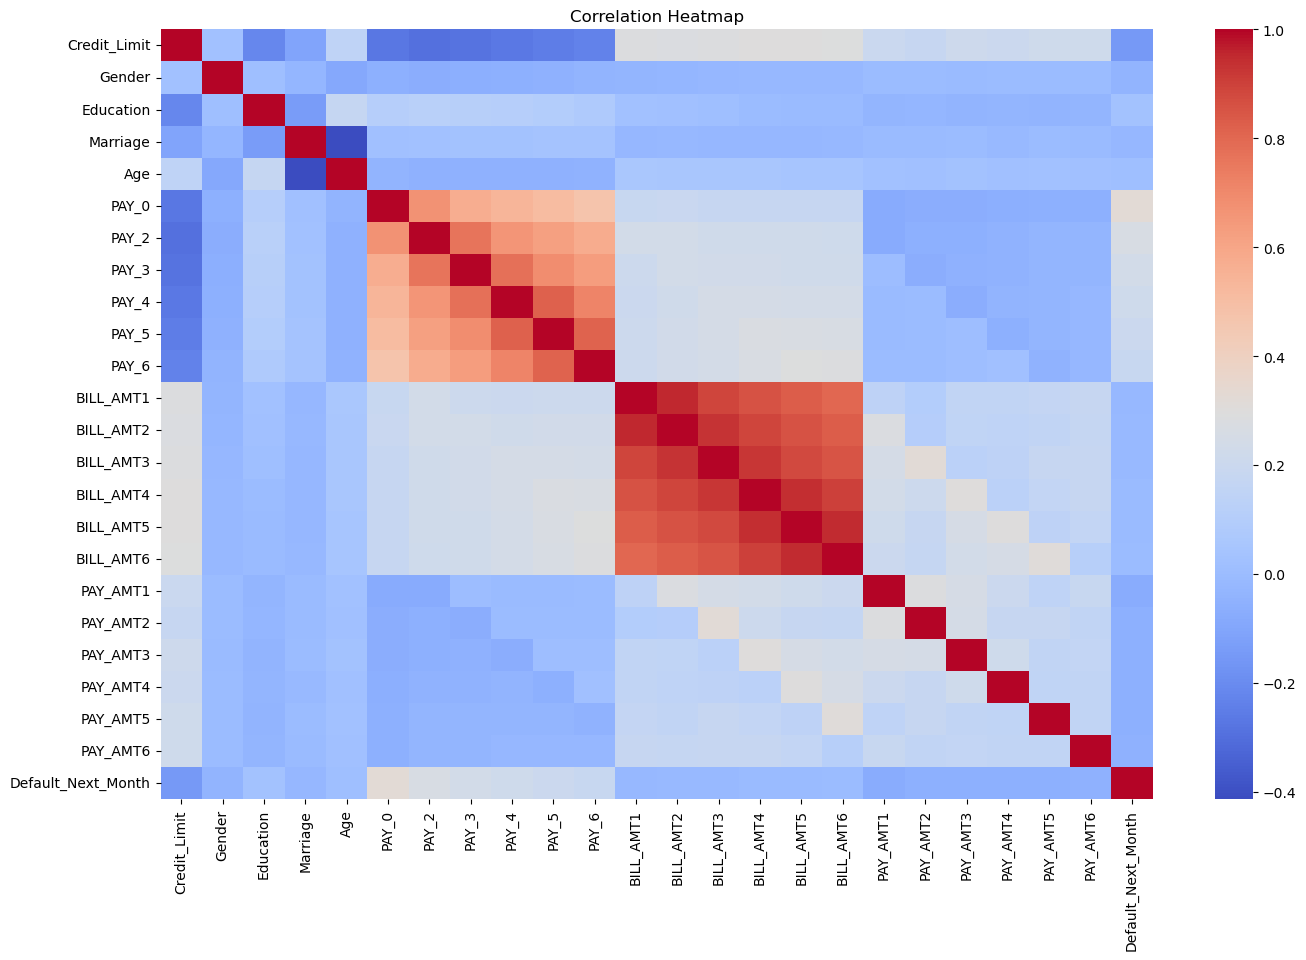

In [48]:
# Create correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.show()

### Interpretation

The correlation heatmap provides an overview of relationships between variables in the dataset. Some repayment status variables appear to have stronger relationships with default behavior compared to demographic variables. This suggests that customer payment history may be one of the most important indicators of future default risk.

## 14. Repayment Status Analysis

Repayment history is expected to be one of the strongest predictors of credit card default. The following visualization examines repayment status patterns among customers.

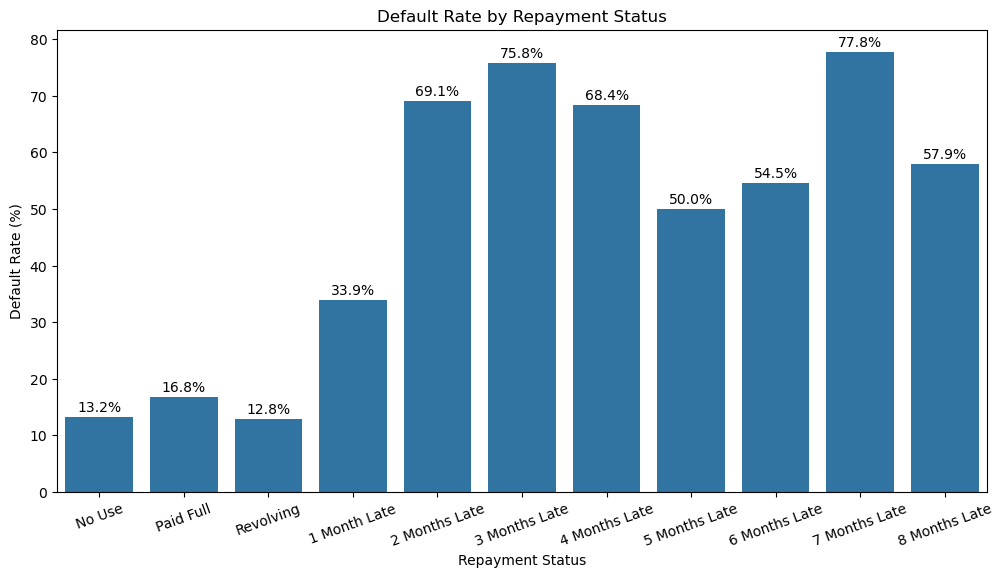

In [49]:
# Calculate default percentage by repayment status
pay0_default_rate = (
    df.groupby('PAY_0')['Default_Next_Month']
    .mean() * 100
).reset_index()

# Create readable labels
pay0_labels = {
    -2: 'No Use',
    -1: 'Paid Full',
     0: 'Revolving',
     1: '1 Month Late',
     2: '2 Months Late',
     3: '3 Months Late',
     4: '4 Months Late',
     5: '5 Months Late',
     6: '6 Months Late',
     7: '7 Months Late',
     8: '8 Months Late'
}

# Replace labels
pay0_default_rate['PAY_0_Label'] = (
    pay0_default_rate['PAY_0']
    .map(pay0_labels)
)

# Plot
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x='PAY_0_Label',
    y='Default_Next_Month',
    data=pay0_default_rate
)

# Add percentage labels on bars
for i, row in pay0_default_rate.iterrows():
    ax.text(
        i,
        row['Default_Next_Month'] + 1,
        f"{row['Default_Next_Month']:.1f}%",
        ha='center'
    )

plt.title('Default Rate by Repayment Status')
plt.xlabel('Repayment Status')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=20)

plt.show()

In [50]:
# Calculate default percentage by repayment status
pay0_default_rate = (
    df.groupby('PAY_0')['Default_Next_Month']
    .mean() * 100
)

# Display percentages
print("\nDefault Rate by PAY_0 Status (%):\n")
print(pay0_default_rate.round(2))


Default Rate by PAY_0 Status (%):

PAY_0
-2    13.23
-1    16.78
 0    12.81
 1    33.95
 2    69.14
 3    75.78
 4    68.42
 5    50.00
 6    54.55
 7    77.78
 8    57.89
Name: Default_Next_Month, dtype: float64


### Interpretation

The repayment status visualization suggests a strong relationship between payment delays and default risk. Customers with larger repayment delays appear more likely to default on their future payments. This pattern supports the idea that payment history is a critical factor in predicting credit card default behavior.

## 15. Education Level and Default Risk

This analysis examines whether education level appears associated with differences in customer default behavior.

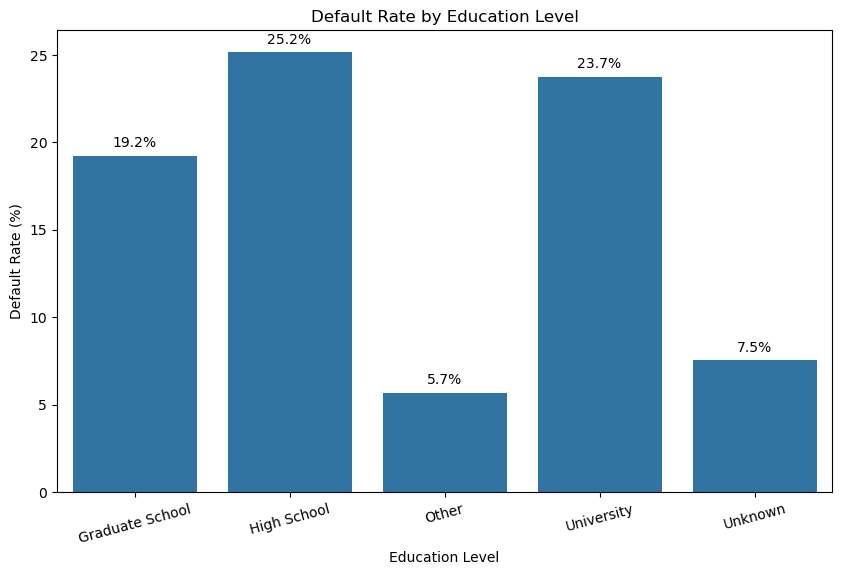


Default Rate by Education Level (%):

         Education  Default_Next_Month
0  Graduate School           19.234766
1      High School           25.157616
2            Other            5.691057
3       University           23.734854
4          Unknown            7.536232


In [51]:
# Create temporary dataframe for plotting
education_plot_df = df.copy()

# Replace education codes ONLY in temporary dataframe
education_plot_df['Education'] = education_plot_df['Education'].replace({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Other',
    5: 'Unknown',
    6: 'Unknown',
    0: 'Unknown'
})

# Calculate default percentage by education
education_default_rate = (
    education_plot_df.groupby('Education')['Default_Next_Month']
    .mean() * 100
).reset_index()

# Plot default percentages
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Education',
    y='Default_Next_Month',
    data=education_default_rate
)

# Add percentage labels above bars
for i, row in education_default_rate.iterrows():
    ax.text(
        i,
        row['Default_Next_Month'] + 0.5,
        f"{row['Default_Next_Month']:.1f}%",
        ha='center'
    )

plt.title('Default Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=15)

plt.show()

# Display summary table
print("\nDefault Rate by Education Level (%):\n")
print(education_default_rate)

### Interpretation

The visualization compares default patterns across different education levels. Although some variation may exist between groups, additional statistical analysis and machine learning evaluation are needed to determine the true predictive strength of education-related variables.

## 16. Preparing Features and Target Variable

Before building machine learning models, the dataset must be separated into predictor variables and the target variable. The target variable for this project is whether the customer defaulted on their credit card payment the following month.

In [52]:
# Define target variable
y = df['Default_Next_Month']

# Define predictor variables
X = df.drop('Default_Next_Month', axis=1)

# Display shape
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (30000, 23)
Target variable shape: (30000,)


## 17. Splitting Training and Testing Data

The dataset is divided into training and testing subsets. The training data will be used to build machine learning models, while the testing data will evaluate model performance on unseen data.

In [53]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24000, 23)
X_test shape: (6000, 23)
y_train shape: (24000,)
y_test shape: (6000,)


## 18. Feature Scaling

Feature scaling standardizes numerical variables so they are measured on a similar scale. This process is especially important for algorithms such as Logistic Regression.

In [54]:
# Initialize scaler
scaler = StandardScaler()

# Scale training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 19. Logistic Regression Model

Logistic Regression is commonly used for binary classification problems and serves as a baseline model for predicting credit card default risk.

In [55]:
# Initialize Logistic Regression model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)

# Prediction probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

## 20. Logistic Regression Evaluation

Several evaluation metrics are used to measure the performance of the Logistic Regression model, including accuracy, precision, recall, and ROC-AUC score.

In [56]:
# Evaluation metrics
print("Logistic Regression Results")
print("-----------------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
-----------------------------------
Accuracy: 0.81
Precision: 0.6926503340757239
Recall: 0.23686214775323686
ROC-AUC: 0.7269867506354779

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



### Interpretation

The Logistic Regression model provides baseline predictive performance for identifying customers likely to default on future credit card payments. Evaluation metrics such as precision, recall, and ROC-AUC help measure how effectively the model distinguishes between default and non-default customers. The results suggest that customer payment behavior and financial characteristics contain useful predictive information for default risk classification.

## 21. Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect classifications made by the Logistic Regression model.

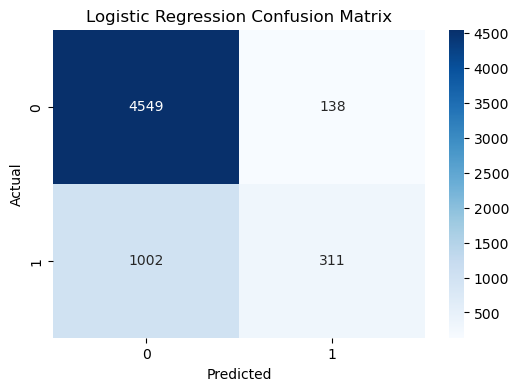


Confusion Matrix Interpretation:

True Negatives (TN): 4549
Customers correctly predicted as non-default.

False Positives (FP): 138
Customers incorrectly predicted as default.

False Negatives (FN): 1002
Customers incorrectly predicted as non-default but actually defaulted.

True Positives (TP): 311
Customers correctly predicted as default.

Percentage Breakdown:

True Negatives: 75.82%
False Positives: 2.30%
False Negatives: 16.70%
True Positives: 5.18%


In [57]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Extract values
tn, fp, fn, tp = cm.ravel()

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Print interpretation
print("\nConfusion Matrix Interpretation:\n")

print(f"True Negatives (TN): {tn}")
print("Customers correctly predicted as non-default.\n")

print(f"False Positives (FP): {fp}")
print("Customers incorrectly predicted as default.\n")

print(f"False Negatives (FN): {fn}")
print("Customers incorrectly predicted as non-default but actually defaulted.\n")

print(f"True Positives (TP): {tp}")
print("Customers correctly predicted as default.\n")

# Calculate percentages
total = cm.sum()

print("Percentage Breakdown:\n")

print(f"True Negatives: {(tn/total)*100:.2f}%")
print(f"False Positives: {(fp/total)*100:.2f}%")
print(f"False Negatives: {(fn/total)*100:.2f}%")
print(f"True Positives: {(tp/total)*100:.2f}%")

## 22. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the model’s ability to distinguish between default and non-default customers across different classification thresholds.

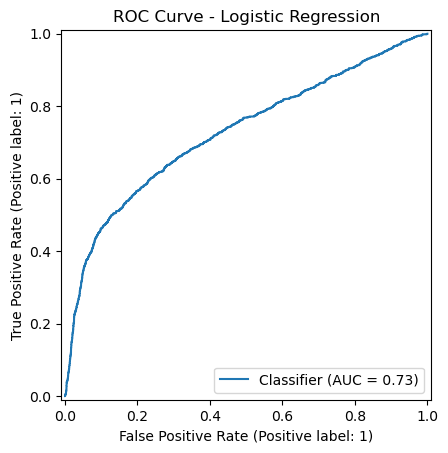

In [58]:
# Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_log)

plt.title('ROC Curve - Logistic Regression')

plt.show()

## 23. Random Forest Model

In addition to Logistic Regression, a Random Forest classifier is used to improve predictive performance and capture non-linear relationships in the data. Random Forest is an ensemble learning method that builds multiple decision trees and combines their results to improve accuracy and stability.

In [59]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## 24. Random Forest Model Evaluation

The performance of the Random Forest model is evaluated using accuracy, precision, recall, and ROC-AUC score. These metrics are compared with Logistic Regression to determine which model performs better for predicting credit card default risk.

In [60]:
print("Random Forest Results")
print("-----------------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
-----------------------------------
Accuracy: 0.816
Precision: 0.6380449141347424
Recall: 0.36785986290936784
ROC-AUC: 0.7577788444679593

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.37      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



## 25. Confusion Matrix - Random Forest

The confusion matrix shows how many cases were correctly and incorrectly classified by the Random Forest model.

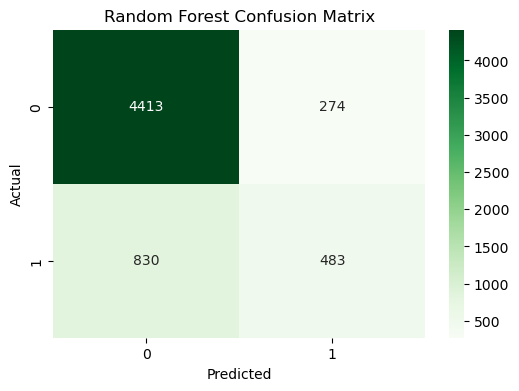


Random Forest Confusion Matrix Interpretation:

True Negatives (TN): 4413
Customers correctly predicted as non-default.

False Positives (FP): 274
Customers incorrectly predicted as default.

False Negatives (FN): 830
Customers incorrectly predicted as non-default but actually defaulted.

True Positives (TP): 483
Customers correctly predicted as default.

Percentage Breakdown:

True Negatives: 73.55%
False Positives: 4.57%
False Negatives: 13.83%
True Positives: 8.05%


In [61]:
# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Extract values
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Print interpretation
print("\nRandom Forest Confusion Matrix Interpretation:\n")

print(f"True Negatives (TN): {tn_rf}")
print("Customers correctly predicted as non-default.\n")

print(f"False Positives (FP): {fp_rf}")
print("Customers incorrectly predicted as default.\n")

print(f"False Negatives (FN): {fn_rf}")
print("Customers incorrectly predicted as non-default but actually defaulted.\n")

print(f"True Positives (TP): {tp_rf}")
print("Customers correctly predicted as default.\n")

# Calculate percentages
total_rf = cm_rf.sum()

print("Percentage Breakdown:\n")

print(f"True Negatives: {(tn_rf/total_rf)*100:.2f}%")
print(f"False Positives: {(fp_rf/total_rf)*100:.2f}%")
print(f"False Negatives: {(fn_rf/total_rf)*100:.2f}%")
print(f"True Positives: {(tp_rf/total_rf)*100:.2f}%")

## 26. Model Comparison Using ROC Curve

The ROC curves for Logistic Regression and Random Forest are compared to evaluate which model performs better in distinguishing between default and non-default customers.

<Figure size 800x600 with 0 Axes>

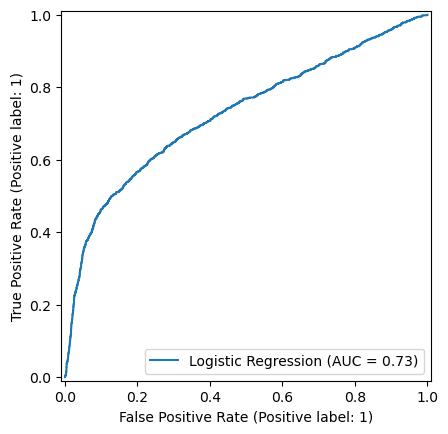

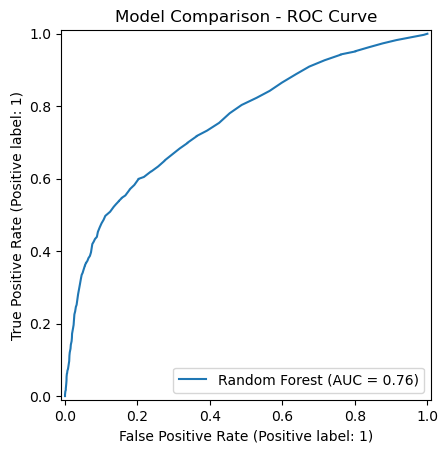

In [62]:
plt.figure(figsize=(8,6))

# Logistic Regression ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name="Logistic Regression"
)

# Random Forest ROC
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("Model Comparison - ROC Curve")
plt.show()

## 27. Feature Importance (Random Forest)

Random Forest allows us to identify which features are most important in predicting credit card default risk. This helps interpret the model and provides business insights for financial decision-making.

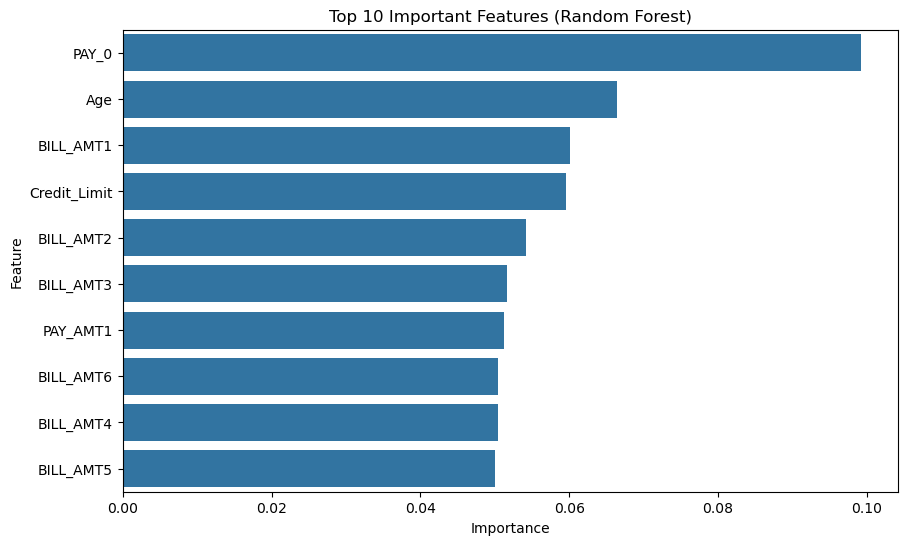

In [63]:
importances = rf_model.feature_importances_

feature_names = X.columns

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)

plt.title('Top 10 Important Features (Random Forest)')
plt.show()